# Eksperimen Preprocessing - Titanic Dataset
**Nama Siswa:** Johan

## 1. Perkenalan Dataset
Dataset yang digunakan adalah **Titanic Dataset** yang bersumber dari [Kaggle - Titanic Machine Learning from Disaster](https://www.kaggle.com/c/titanic).

Dataset ini berisi informasi tentang penumpang kapal Titanic, termasuk fitur demografis dan tiket perjalanan yang digunakan untuk memprediksi apakah seorang penumpang selamat atau tidak.

**Informasi Dataset:**
- **Sumber:** Kaggle / datasciencedojo public repository
- **Jumlah baris:** 891 penumpang
- **Jumlah kolom:** 12 fitur
- **Target variabel:** `Survived` (0 = Tidak Selamat, 1 = Selamat)
- **Tipe masalah:** Binary Classification

## 2. Import Library

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Utilities
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries imported successfully!')

Libraries imported successfully!


## 3. Memuat Dataset

In [23]:
# Load dataset dari public repository
URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(URL)

# Simpan raw dataset ke folder
os.makedirs('titanic_raw', exist_ok=True)
df.to_csv('titanic_raw/titanic_raw.csv', index=False)

print(f'Dataset berhasil dimuat!')
print(f'Shape: {df.shape}  ({df.shape[0]} baris, {df.shape[1]} kolom)')

Dataset berhasil dimuat!
Shape: (891, 12)  (891 baris, 12 kolom)


In [3]:
# Tampilkan 5 baris pertama
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Tampilkan 5 baris terakhir
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


## 4. Exploratory Data Analysis (EDA)

In [5]:
# --- 4.1 Informasi Umum Dataset ---
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# --- 4.2 Statistik Deskriptif ---
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# --- 4.3 Missing Values ---
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values ===')
print(missing_df)

=== Missing Values ===
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


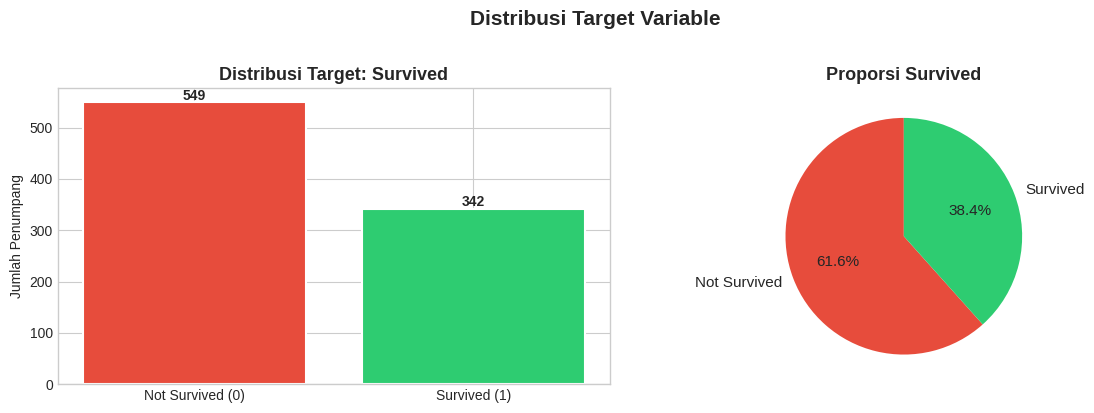

Survival Rate: 38.4%


In [8]:
# --- 4.4 Distribusi Target Variable ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
survived_counts = df['Survived'].value_counts()
axes[0].bar(['Not Survived (0)', 'Survived (1)'], survived_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Target: Survived', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Penumpang')
for i, v in enumerate(survived_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survived_counts.values, labels=['Not Survived', 'Survived'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Survived', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Target Variable', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Survival Rate: {df["Survived"].mean()*100:.1f}%')

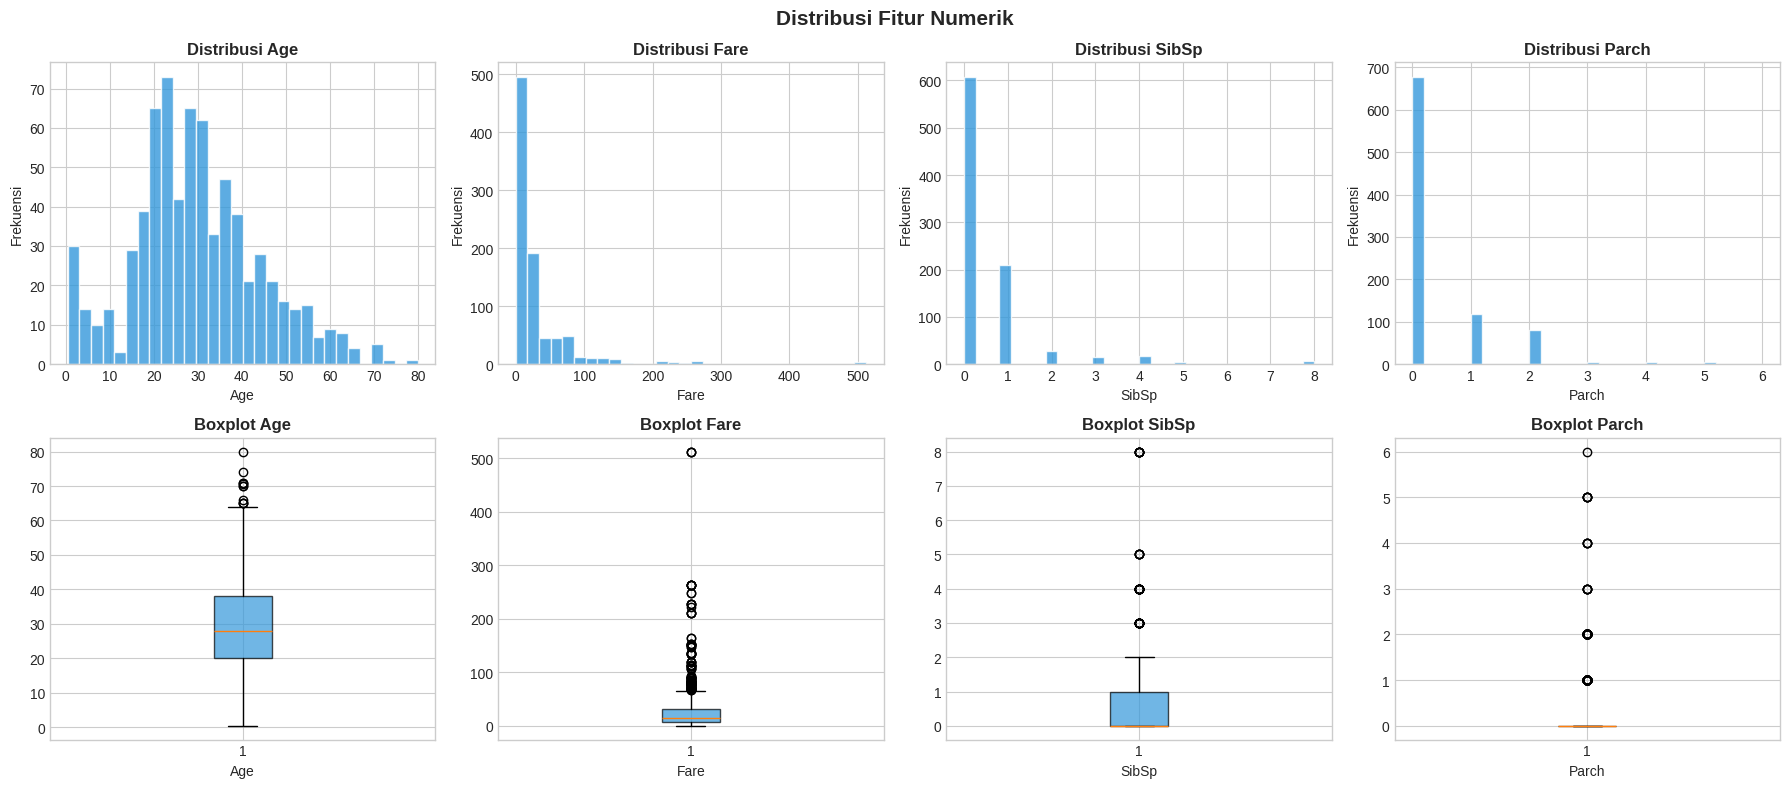

In [9]:
# --- 4.5 Distribusi Fitur Numerik ---
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.7))
    axes[1, i].set_title(f'Boxplot {col}', fontweight='bold')
    axes[1, i].set_xlabel(col)

plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

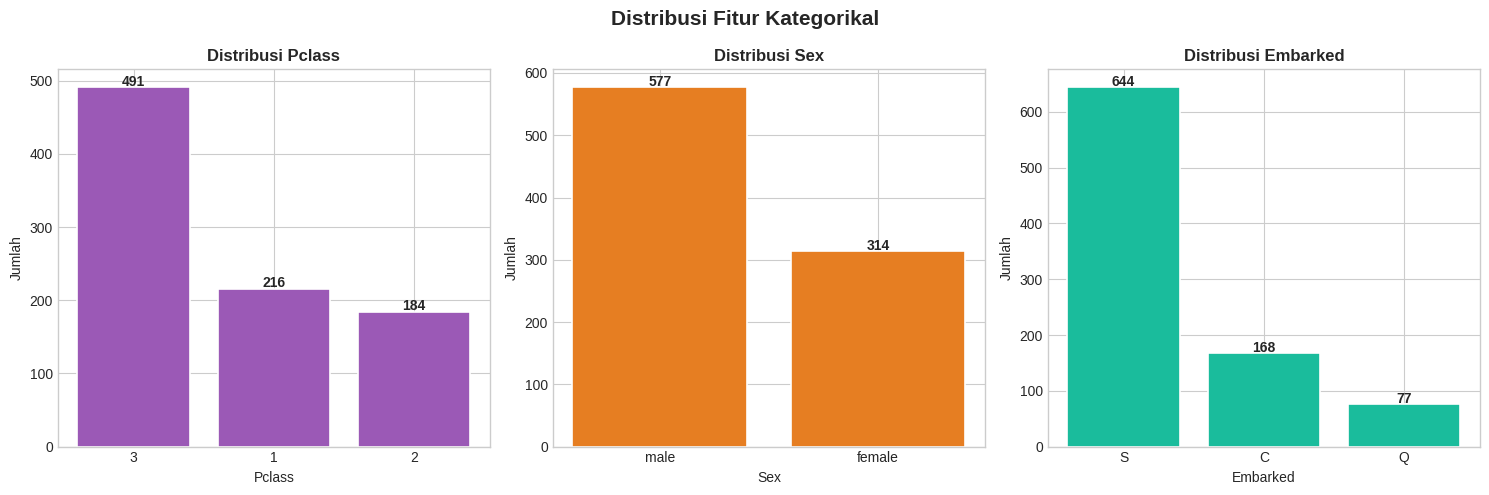

In [10]:
# --- 4.6 Distribusi Fitur Kategorikal ---
cat_cols = ['Pclass', 'Sex', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors_list = ['#9b59b6', '#e67e22', '#1abc9c']
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=colors_list[i], edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 2, str(v), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

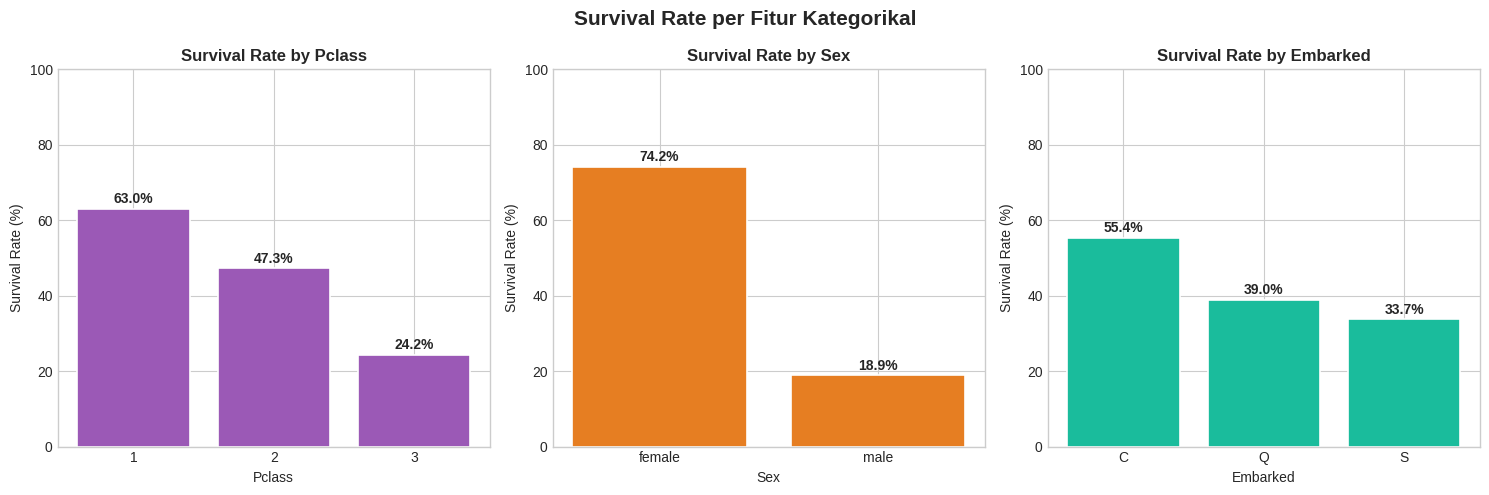

In [11]:
# --- 4.7 Survival Rate per Fitur ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    survival = df.groupby(col)['Survived'].mean() * 100
    axes[i].bar(survival.index.astype(str), survival.values,
                color=colors_list[i], edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'Survival Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Survival Rate (%)')
    axes[i].set_ylim(0, 100)
    for j, v in enumerate(survival.values):
        axes[i].text(j, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Survival Rate per Fitur Kategorikal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

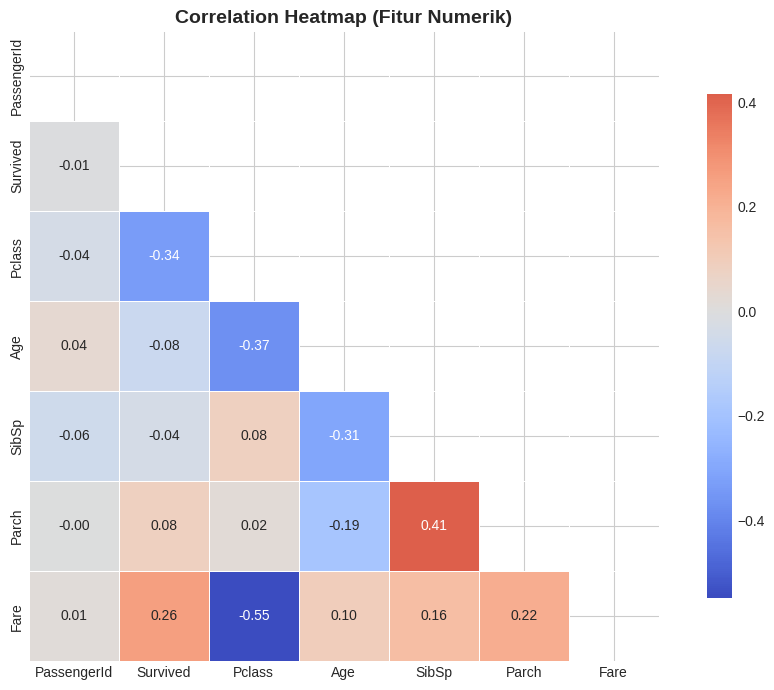

In [12]:
# --- 4.8 Correlation Heatmap ---
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Fitur Numerik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# --- 4.9 Deteksi Outlier (IQR Method) ---
print('=== Deteksi Outlier (IQR Method) ===')
for col in ['Age', 'Fare', 'SibSp', 'Parch']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:8s} → Batas bawah: {lower:7.2f} | Batas atas: {upper:7.2f} | Outlier: {n_outliers}')

=== Deteksi Outlier (IQR Method) ===
Age      → Batas bawah:   -6.69 | Batas atas:   64.81 | Outlier: 11
Fare     → Batas bawah:  -26.72 | Batas atas:   65.63 | Outlier: 116
SibSp    → Batas bawah:   -1.50 | Batas atas:    2.50 | Outlier: 46
Parch    → Batas bawah:    0.00 | Batas atas:    0.00 | Outlier: 213


## 5. Data Preprocessing

In [14]:
# Buat salinan dataframe
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

Shape awal: (891, 12)


In [15]:
# --- 5.1 Menghapus Kolom Tidak Relevan ---
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean.drop(columns=drop_cols, inplace=True)

print(f'Kolom dihapus: {drop_cols}')
print(f'Shape setelah drop: {df_clean.shape}')

Kolom dihapus: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Shape setelah drop: (891, 8)


In [16]:
# --- 5.2 Menangani Data Kosong (Missing Values) ---
print('Missing values SEBELUM penanganan:')
print(df_clean.isnull().sum())

# Age → isi dengan median
age_median = df_clean['Age'].median()
df_clean['Age'].fillna(age_median, inplace=True)

# Embarked → isi dengan modus
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(embarked_mode, inplace=True)

print('\nMissing values SETELAH penanganan:')
print(df_clean.isnull().sum())

Missing values SEBELUM penanganan:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Missing values SETELAH penanganan:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [17]:
# --- 5.3 Menghapus Data Duplikat ---
n_dup = df_clean.duplicated().sum()
print(f'Jumlah duplikat ditemukan: {n_dup}')

if n_dup > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f'Duplikat dihapus. Shape baru: {df_clean.shape}')
else:
    print('Tidak ada data duplikat.')

Jumlah duplikat ditemukan: 116
Duplikat dihapus. Shape baru: (775, 8)


In [18]:
# --- 5.4 Deteksi dan Penanganan Outlier (Fare dengan IQR) ---
Q1   = df_clean['Fare'].quantile(0.25)
Q3   = df_clean['Fare'].quantile(0.75)
IQR  = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = ((df_clean['Fare'] < lower_bound) | (df_clean['Fare'] > upper_bound)).sum()
print(f'Outlier Fare ditemukan: {n_outliers}')
print(f'Batas bawah: {lower_bound:.2f} | Batas atas: {upper_bound:.2f}')

# Cap outlier (Winsorization) alih-alih dihapus agar data tidak berkurang signifikan
df_clean['Fare'] = df_clean['Fare'].clip(lower=lower_bound, upper=upper_bound)
print('Outlier Fare di-cap (Winsorization).')

Outlier Fare ditemukan: 102
Batas bawah: -31.17 | Batas atas: 73.42
Outlier Fare di-cap (Winsorization).


In [19]:
# --- 5.5 Encoding Data Kategorikal ---
le = LabelEncoder()

df_clean['Sex']      = le.fit_transform(df_clean['Sex'])       # male=1, female=0
df_clean['Embarked'] = le.fit_transform(df_clean['Embarked'])  # C=0, Q=1, S=2

print('Encoding selesai.')
print(df_clean[['Sex', 'Embarked']].head())

Encoding selesai.
   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2


In [20]:
# --- 5.6 Normalisasi / Standarisasi Fitur ---
scaler     = StandardScaler()
scale_cols = ['Age', 'Fare']

df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print(f'Standarisasi selesai untuk kolom: {scale_cols}')
df_clean[scale_cols].describe().round(4)

Standarisasi selesai untuk kolom: ['Age', 'Fare']


,Age,Fare
count,775.0000,775.0000
mean,0.0000,-0.0000
std,1.0006,1.0006
min,-2.1197,-1.1634
25%,-0.6237,-0.8112
50%,-0.1149,-0.4678
75%,0.4666,0.3327
max,3.6648,2.0486


In [21]:
# --- Hasil Akhir Preprocessing ---
print('=== Hasil Akhir ===')
print(f'Shape akhir  : {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print('\nSampel data:')
df_clean.head()

=== Hasil Akhir ===
Shape akhir  : (775, 8)
Missing values: 0

Sampel data:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.551060,1,0,-0.846218,2
1,1,1,0,0.611945,1,0,1.955092,0
2,1,3,0,-0.260308,0,0,-0.816688,2
3,1,1,0,0.393881,1,0,1.159615,2
4,0,3,1,0.393881,0,0,-0.811220,2


In [22]:
# Simpan hasil preprocessing
os.makedirs('titanic_preprocessing', exist_ok=True)
df_clean.to_csv('titanic_preprocessing/titanic_preprocessing.csv', index=False)
print('Preprocessed dataset disimpan ke: titanic_preprocessing/titanic_preprocessing.csv')

Preprocessed dataset disimpan ke: titanic_preprocessing/titanic_preprocessing.csv
